# After good earnings, does the extra return wait for a breakout?

In [1]:

from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
ROOT = Path.cwd() if (Path.cwd() / "outputs").exists() else Path.cwd().parent
T, F = ROOT / "outputs" / "tables", ROOT / "outputs" / "figures"
def load(name, **kw): return pd.read_csv(T / name, **kw)
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)


*Lei Kam Fai (Woody). Quant Team Recruitment, Round 1. 14 September 2026. Data: Massive API and SEC EDGAR.*

## The answer in one paragraph

A popular trading rule says: after a great earnings report, wait until the stock closes above its earnings-day high, then buy. I tested whether the extra return really arrives after that "breakout". I used 14,770 US earnings days from 2005 to 2026 where the stock jumped into the top 10% of reactions. **It does not.** After a breakout, the stock earns 0.9 basis points a day above the market; the same stocks earn 1.8 a day over the same days whether or not they broke out. Waiting for the breakout earned *less* than buying the next morning (about 0.9% less per trade before 2015, about the same after). Buying the next morning earned about 1.4% over 40 days before 2015 and nothing since, and trading costs of about 1% per round trip wipe that out. **The idea is rejected.**

## 1. The question

Some stocks keep rising for weeks after a strong earnings report. Traders call this drift. The question is not *how much* drift there is, but *when* it arrives: steadily from the next day, or mostly after the stock first closes above the high of the earnings day?

## 2. The idea, and the trap in it

Two rules on the same stock, same earnings day, same 40-day window:

| Rule | Buys | Sells |
|---|---|---|
| **A** | next morning at the open | close of day 40 |
| **B** | the morning after the first close above the earnings-day high | close of day 40 |

If drift arrives only after the breakout, B should earn more than A. But look at a made-up stock that faded from its high on the earnings day (about half of real cases close well below their high):

| Day | Price | What happens |
|---|---|---|
| Day -1 close | 90 | the day before the report |
| Day 0 (earnings day) | opens up, trades as high as 104, closes at 100 | reaction +11%; the "earnings-day high" is 104 |
| Day 1 open | 100 | **A buys** (the stock opens where it closed) |
| Day 2 close | 102 | still below 104, B waits |
| Day 3 close | 105 | first close above 104: B's signal |
| Day 4 open | 105 | **B buys** |
| Day 40 close | 110 | both sell |

A makes +10% (100 to 110). B makes +4.8% (105 to 110). The figure shows the same path.


### Why Rule A must beat Rule B on breakout cases

On any case where the stock breaks out, both rules hold the same position from B's entry to the end. The only difference is that A also held the stock from day 1 until B's entry. So:

> **A's return = (1 + run-up) x (1 + B's return) - 1**, where the run-up is the price move from A's buy price to B's buy price.

B buys only after a close *above the day-0 high*, and A bought at the day-1 open, which is almost always *below* that high. So the run-up is positive in 88% of breakout cases (average +3.8%), and A's return is larger than B's on almost every one of them. In the example: (1 + 5%) x (1 + 4.8%) - 1 = 10%.

B can therefore only win *on average* if the stocks that *never* break out fall a lot, because on those B earns 0 while A takes the loss. In our data, 61% of cases break out (A +4.2%, B +0.3%) and 39% do not (A -5.1%, B 0). "B beats A" is a statement about the losers, not about *when* drift arrives. This trap shaped the whole design: the main test in section 6 compares only the part of the return that a breakout trader actually receives.

In [2]:
import sys; sys.path.insert(0, str(ROOT / "scripts"))
from make_toy_figure import draw
fig, ax = plt.subplots(figsize=(9, 4.8)); draw(ax); plt.tight_layout(); plt.show()

/var/folders/7g/127qcld14ddc55nlgjm5sn480000gn/T/ipykernel_75982/113331719.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig, ax = plt.subplots(figsize=(9, 4.8)); draw(ax); plt.tight_layout(); plt.show()


## 3. Data

| Source | What | Size | Used for |
|---|---|---|---|
| Massive: Daily Market Summary | open, high, low, close, volume for every US stock, each weekday 2004 to Sep 2026 | 5,988 calls, 23 files | prices, returns, SPY benchmark |
| Massive: All Tickers | every ticker, live and dead, with company ID (CIK) | 36,588 rows | link filings to prices; keep delisted stocks |
| Massive: Splits | every split and stock dividend | 27,541 rows | adjust prices ourselves |
| SEC EDGAR submissions (free, public) | every 8-K filing with the exact time the SEC accepted it | 321,077 earnings 8-Ks, 9,679 companies | date each earnings event |

Prices were downloaded *unadjusted* and split-adjusted by us, so price filters use the real price of the day. Our adjustment matches the vendor's own adjusted prices (tested). Raw data is not in the repository (licence); all summary tables are.

**Why EDGAR.** Massive's 8-K endpoints give a filing *date* but no time, and their earnings tags start in 2020 and miss most releases. EDGAR gives the acceptance time to the second. It is public and free, and the time it shows is the time the news became public.

### Cleaning and checks

| Data | Problem | What we did | Where |
|---|---|---|---|
| Prices | vendor's adjusted prices rescale history to today's share count, so a $5 filter would look at the wrong price | downloaded unadjusted prices; applied split factors ourselves; checked against the vendor's factors (all tickers) and adjusted prices (split tickers) | `prices.py`, `test_prices.py`, `test_api_crosscheck.py` |
| Prices | duplicate rows across pages | dropped duplicate (ticker, date) rows | `panel.py` |
| Prices | holidays and missing days | trading calendar = days SPY traded; a return is missing if the previous day's bar is missing | `panel.py` |
| Prices | ETFs, warrants, preferreds, OTC names mixed in | kept common stocks (type CS) on NYSE, Nasdaq, NYSE American, plus SPY | `panel.py`, `events.py` |
| Prices | bad bars | tested: high >= open and close, low <= open and close in 99.8% of bars; closes positive; about 252 days per year | `test_prices.py` |
| Tickers | one symbol reused by two companies over time | each ticker record is valid only between the previous namesake's delisting and its own | `panel.py` |
| Tickers | companies with several share classes | kept the most liquid class per event | `events.py` |
| Filings | amendments and repeat filings | dropped 8-K/A; one event per company per day 0; dropped follow-ups within 20 sessions | `events.py` |
| Filings | times are in UTC; SEC dates shift after 17:30 New York time | used the acceptance time converted to New York time, not the filing date | `edgar.py`, `test_edgar.py` |
| Filings | 8-K can lag the press release | measured: biggest move on day 0 for 64% of events, day +1 for 20%; reported as a limit | `timing_validation.csv` |
| Events | reaction needs two consecutive bars | required a bar on day -1 and day 0; 1 event had no day-1 open and was dropped from return tables | `events.py`, `test_events.py` |
| Events | nothing from the future | tested: threshold built only from earlier quarters; filters use day -1 data; every buy is after its signal | `test_events.py` |
| Vendor | two Massive endpoints disagree on about 1% of days by more than 1% | used one endpoint (Daily Market Summary) throughout; noted | decision log 01:10 |

## 4. How each event was built

1. Take every 8-K with Item 2.02 (earnings release).
2. **Day 0** = the first session that could react: filed before 09:30 New York time, same day; filed after 16:00, next trading day; filed during the session, set aside as "unclear" (used only in a check).
3. Link the company to its stock through the CIK, including stocks that no longer trade.
4. Keep US common stocks on NYSE, Nasdaq or NYSE American, price at least $5, median daily dollar volume over the previous 60 days at least $1 million, at least 120 days of history. All measured *before* day 0. Dollar volume is the size and liquidity screen (point-in-time market cap is not in the daily data); the selected events have a median $13 million traded per day and a median price of $26, and results are also split by liquidity third and re-run with a $5 million floor (section 9).
5. Measure the day-0 reaction: return from the day before to day 0, minus SPY.
6. Keep a "strong report" if the reaction is in the top 10% of the *previous four quarters*. This threshold was knowable on the day; ranking within the same quarter would use the future. Four other definitions (a fixed +5%, a reaction of 2 standard deviations, an overnight gap-up of 2 standard deviations, a gap-up of 5%) are run as checks in section 9 and give the same answer.

Result: 14,770 strong reports, 3,116 stocks, 86 quarters. Median reaction +12.4%. 22% are stocks that later delisted. Check on the dating: for 64% of events the biggest move falls on our day 0, for about 20% one day later (an 8-K filed hours after the press release). This noise hits Rules A and B equally.

In [3]:
display(load("sample_funnel.csv").rename(columns={"step": "step", "n_events": "events left"}))
display(load("timing_validation.csv", index_col=0).round(2).rename(columns={"peak_on_d0": "biggest move on day 0", "peak_on_dm1": "on day -1", "peak_on_d1": "on day +1"}))

,step,events left
0,edgar_item202_rows,321077
1,8k_not_amended,318081
2,unique_cik_day0,316021
3,with_candidate_ticker,311923
4,matched_to_prices,288469
5,after_dedupe_20d,271534
6,exchange_filter,271460
7,plus_price_filter,226721
8,plus_liquidity_filter,184493
9,plus_history_filter,181927


,biggest move on day 0,on day -1,on day +1,n
timing,,,,
amc,0.65,0.16,0.20,72264.0
bmo,0.64,0.13,0.23,73545.0
intraday,0.34,0.18,0.48,36118.0
all,0.58,0.15,0.27,181927.0


## 5. The rules and the controls

Days are trading days after day 0. H = holding length (40). W = longest wait for a breakout (10).

| Rule | Buys at the open of | Condition | What it tests |
|---|---|---|---|
| **A** | day 1 | none | plain drift |
| **B** | day k+1 | first close above the **day-0 high** on day k (k up to W); else no trade | the breakout idea |
| **C** | day 3 | none (day 2 is B's typical signal day) | is it just the waiting? |
| **D1 / D2 / D3** | day k+1 | first close above the day-0 *close* / 3% above the high / the day-1 high | is the earnings-day high special? |

All sell at the close of day H. Returns are "abnormal": the stock's return minus SPY's over the same span. If a stock stops trading inside the window, it is sold at its last price (17 cases).

## 6. What we measure

* **Main test.** For each breakout case, the abnormal return *per day* from its entry to day H, compared with what *all* strong-report stocks in the same quarter earned per day over those *same* days. This compares like with like and avoids the trap in section 2.
* **Second test.** Rule B's 40-day return minus Rule A's.
* **Uncertainty.** Earnings come in four seasons a year, so events are not independent. Every number carries a 95% range from resampling whole quarters (86 of them, 5,000 times). If the range includes zero, the effect is not distinguishable from zero.
* **Two settings only.** W (5, 10, 15, 20) and H (20, 40, 60). The default (10, 40) was fixed before any result. 2005 to 2014 picks the best cell; 2015 to 2026 reports it. All other choices (the $5, the $1 million, the top 10%) were fixed once and later checked, not tuned.

## 7. Results (W = 10, H = 40)

| What | 2005 to 2026 | 2005 to 2014 | 2015 to 2026 |
|---|---|---|---|
| Rule A, 40-day return | **+0.55%** (-0.50 to +1.59) | +1.43% (+0.57 to +2.35) | +0.12% (-1.29 to +1.55) |
| Rule B, 40-day return | +0.21% | +0.51% | +0.06% |
| B minus A | **-0.34%** (-0.87 to +0.20) | **-0.92%** (-1.41 to -0.46) | -0.06% (-0.77 to +0.67) |
| After breakout, per day | 0.9 bp | | |
| Same days, all cases, per day | 1.8 bp | | |
| **Main test: difference per day** | **-0.9 bp** (-1.5 to -0.2) | -1.5 bp (-2.4 to -0.6) | -0.6 bp (-1.4 to +0.3) |

*bp = basis point = 0.01%. Ranges are 95% confidence intervals.*

**Three things to see.**

1. **Drift is small and old.** Buying the next morning earned +1.4% before 2015 and nothing after (Figure 1). This matches published work saying the drift has faded.
2. **Nothing extra after the breakout.** 61% of cases broke out within 10 days, 45% of them on day 1. After the entry they earned 0.9 bp a day; the normal path was 1.8 bp a day. If anything, slightly less (Figure 2). A gap of 1 bp a day is about 0.4% over the window.
3. **Waiting lost money.** B trailed A in every period, clearly before 2015. Why: breakout cases earned +4.2% under A but only +0.3% under B (the run-up was +3.8%); the 39% that never broke out lost 5.1% under A while B sat out.

**Controls.** C (buy on day 3, no signal) earned +0.45%. D1, D2, D3 earned +0.40%, +0.08%, +0.12%. Every "wait for a higher close" rule behaves like B. The earnings-day high is not a special level.

In [4]:
cp = load("car_path_means.csv")
fig, ax = plt.subplots(figsize=(8, 4))
for per, c, lab in (("all_2005_2026", "k", "all"), ("selection_2005_2014", "tab:blue", "2005-2014"), ("holdout_2015_2026", "tab:red", "2015-2026")):
    d = cp[cp.period == per]; ax.plot(d.day, d.mean_car_pct, color=c, label=lab); ax.fill_between(d.day, d.ci_lo_pct, d.ci_hi_pct, color=c, alpha=0.12)
ax.axhline(0, color="gray", lw=0.8); ax.set_xlabel("trading days after day 0"); ax.set_ylabel("Rule A return above market, %"); ax.legend(); ax.set_title("Figure 1. Return after a strong report (shaded = 95% range)"); plt.show()
ba = load("breakout_aligned_means.csv")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ba.tau, ba.breakout_events_mean_ar_bp, "o-", color="tab:red", label="breakout cases"); ax.plot(ba.tau, ba.matched_unconditional_mean_ar_bp, "s--", color="gray", label="all cases, same days")
ax.axvline(0, color="k", ls=":", lw=0.8); ax.axvline(1, color="tab:green", ls=":", lw=0.8); ax.set_xlabel("days before / after the breakout day"); ax.set_ylabel("daily return above market, bp"); ax.legend(); ax.set_title("Figure 2. The breakout day is a spike; afterwards, nothing extra"); plt.show()
dec = load("decomposition_W10_H40.csv"); dec = dec[dec.period == "all_2005_2026"][["group", "n", "share", "CAR_A", "CAR_B", "run_up_open1_to_entry"]]
display(dec.rename(columns={"group": "cases", "share": "share of cases", "CAR_A": "Rule A", "CAR_B": "Rule B", "run_up_open1_to_entry": "run-up B skipped"}).style.format({"share of cases": "{:.0%}", "Rule A": "{:+.2%}", "Rule B": "{:+.2%}", "run-up B skipped": "{:+.2%}"}, na_rep=""))

/var/folders/7g/127qcld14ddc55nlgjm5sn480000gn/T/ipykernel_75982/3114406358.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.axhline(0, color="gray", lw=0.8); ax.set_xlabel("trading days after day 0"); ax.set_ylabel("Rule A return above market, %"); ax.legend(); ax.set_title("Figure 1. Return after a strong report (shaded = 95% range)"); plt.show()
/var/folders/7g/127qcld14ddc55nlgjm5sn480000gn/T/ipykernel_75982/3114406358.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.axvline(0, color="k", ls=":", lw=0.8); ax.axvline(1, color="tab:green", ls=":", lw=0.8); ax.set_xlabel("days before / after the breakout day"); ax.set_ylabel("daily return above market, bp"); ax.legend(); ax.set_title("Figure 2. The breakout day is a spike; afterwards, nothing extra"); plt.show()


,cases,n,share of cases,Rule A,Rule B,run-up B skipped
0,all events,14769,100%,+0.55%,+0.21%,+3.79%
1,breakout within W,8974,61%,+4.19%,+0.34%,+3.79%
2,no breakout within W,5795,39%,-5.10%,+0.00%,


**How to read Figure 2.** Day 0 here is the *breakout* day, not the earnings day. The red spike at 0 is large by definition: a breakout is a day the stock rose. Everything right of the green line is what a Rule B trader actually gets. It sits on or just under the grey line.

**Same result in calendar time.** Averaging all open positions each day, the A book earned 2.9 bp a day (t = 2.5), the B book 1.1 bp, and B minus A was -1.8 bp a day (t = -2.9). Before 2015: A 5.2 bp (t = 3.8); after: 0.8 bp (t = 0.5).

## 8. Does the choice of W and H matter? No.

B minus A is negative in all 12 cells for 2005 to 2014 (the range is below zero in 11) and not distinguishable from zero in all 12 cells for 2015 to 2026. The main test stays between -1.8 and +0.3 bp a day everywhere. The cell picked on 2005 to 2014 was W = 20, H = 60; on 2015 to 2026 it gives -0.1 bp a day (-0.7 to +0.5) and B minus A of +0.17% (-0.58 to +0.91).

selection_2005_2014 : B minus A, %


H,20,40,60
W,,,
5,-0.45,-0.96,-0.70
10,-0.44,-0.92,-0.74
15,-0.42,-0.81,-0.69
20,-0.42,-0.78,-0.68


holdout_2015_2026 : B minus A, %


H,20,40,60
W,,,
5,-0.15,-0.04,0.19
10,-0.13,-0.06,0.10
15,-0.08,0.03,0.23
20,-0.10,-0.03,0.17


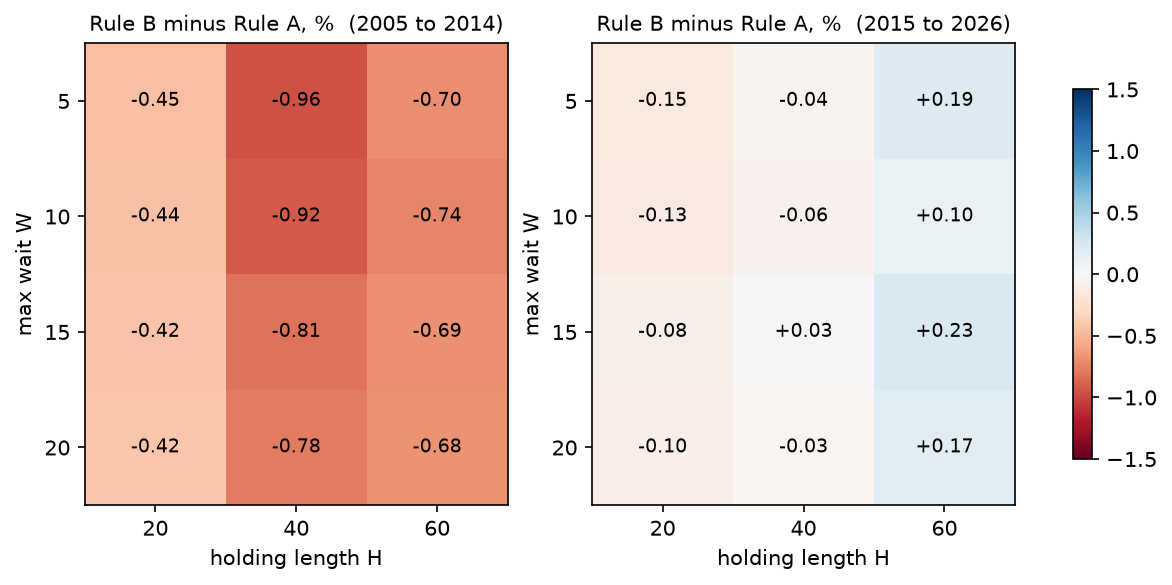

In [5]:
g = load("grid_results.csv")
for per in ("selection_2005_2014", "holdout_2015_2026"):
    print(per, ": B minus A, %"); display((g[g.label == per].pivot(index="W", columns="H", values="B_minus_A") * 100).round(2))
display(Image(filename=str(F / "fig5_grid_B_minus_A.png")))

## 9. Checks

Every check ran through the same code and is logged in `logs/experiment_record.csv`.

| Check | B minus A | Extra drift after breakout (bp/day) | Meaning |
|---|---|---|---|
| Base | -0.34% | -0.9 (-1.5 to -0.2) | |
| Ignore day-1 breakouts | -0.37% | -0.9 | not a day-1 artefact |
| Buy at the signal close, not next open | -0.41% | -1.2 | faster fills do not help |
| "Strong" = at least +5% (26,610 cases) | -0.18% | -0.7 | same picture |
| "Strong" = reaction of 2 standard deviations (35,515) | -0.07% | -0.5 | same picture |
| "Strong" = overnight **gap-up** of 2 standard deviations (25,776) | -0.03% | -0.7 (-1.2 to -0.2) | same picture; Rule A only +0.08% |
| "Strong" = overnight gap-up of at least 5% (18,173) | -0.24% | -1.1 | same picture |
| Top 15% / top 5% instead of top 10% | -0.24% / -0.54% | -0.8 / -1.2 | same picture |
| Price at least $10 / volume at least $5M | -0.22% / -0.21% | -0.7 / -0.8 | same picture |
| Include "unclear" filing times | -0.38% | -0.8 | same picture |
| **Placebo: same stocks, 60 days earlier, no news** | -0.40% | -0.4 (-1.2 to +0.3) | B trails A even without news: the gap is mechanical |
| Mirror on the short side (worst 10%, break below the low) | -0.50% | -1.1 | symmetric; borrowing costs ignored |
| Friday announcements (22% of cases) | -0.16% | -2.8 (-4.7 to -0.8) | wrong sign for an "inattention" story; one split of many |
| Least / middle / most liquid third | -0.48% / -0.05% / -0.49% | | not an illiquid-stock effect |
| Close near day-0 low / middle / high | -0.70% / -0.31% / -0.01% | | B loses most where the high really binds |

**Does a longer consolidation mean more drift after the breakout?** No. Splitting breakout cases by how many days they took to break out: after a day-1 breakout, 1.4 bp a day versus 1.4 for the normal path (difference -0.0, range -1.3 to +1.3); days 2 to 3, 0.1 versus 1.6 (-1.5, range -3.0 to -0.1); days 4 to 6, 2.2 versus 2.3 (-0.2, range -2.1 to +1.8); days 7 to 10, -0.9 versus 2.6 (-3.5, range -6.4 to -0.7). Holding for two or three times the consolidation length instead of a fixed 40 days (average 11 to 13 days held) gives -2.0 and -2.1 bp a day against the normal path (ranges -3.6 to -0.5 and -3.5 to -0.8). Longer consolidations do worse, not better.

**Costs.** Estimated bid-ask spread (from daily highs and lows): median 0.82%, mean 0.96%. Half the spread plus 5 bp per side is about 1.06% per round trip.

| | Before costs | After costs |
|---|---|---|
| Rule A, 2005 to 2026 | +0.55% | -0.52% (-1.55 to +0.52) |
| Rule A, 2005 to 2014 | +1.43% | +0.43% (-0.43 to +1.35) |
| Rule A, 2015 to 2026 | +0.12% | -0.97% (-2.37 to +0.45) |
| Rule B, 2005 to 2026 | +0.21% | -0.45% (-1.01 to +0.14) |

Nothing here is tradable.

In [6]:
rb = load("robustness_W10_H40.csv"); rb = rb[rb.period == "all"].copy()
for c in ("PRIMARY_post_minus_matched", "PRIMARY_lo", "PRIMARY_hi"): rb[c] = rb[c] * 1e4
show = rb[["variant", "n_events", "B_minus_A", "B_minus_A_lo", "B_minus_A_hi", "PRIMARY_post_minus_matched", "PRIMARY_lo", "PRIMARY_hi"]].rename(columns={"n_events": "cases", "B_minus_A": "B minus A", "B_minus_A_lo": "lo", "B_minus_A_hi": "hi", "PRIMARY_post_minus_matched": "extra drift (bp/day)", "PRIMARY_lo": "lo ", "PRIMARY_hi": "hi "})
display(show.style.format({"B minus A": "{:+.2%}", "lo": "{:+.2%}", "hi": "{:+.2%}", "extra drift (bp/day)": "{:+.1f}", "lo ": "{:+.1f}", "hi ": "{:+.1f}"}))
c = load("costs_W10_H40.csv")[["group", "n", "median_spread", "gross_A", "net_A", "net_A_lo", "net_A_hi", "gross_B", "net_B"]]
display(c.rename(columns={"median_spread": "median spread", "gross_A": "A before", "net_A": "A after", "net_A_lo": "lo", "net_A_hi": "hi", "gross_B": "B before", "net_B": "B after"}).style.format({"median spread": "{:.2%}", "A before": "{:+.2%}", "A after": "{:+.2%}", "lo": "{:+.2%}", "hi": "{:+.2%}", "B before": "{:+.2%}", "B after": "{:+.2%}"}))

,variant,cases,B minus A,lo,hi,extra drift (bp/day),lo,hi
0,base top-decile trailing threshold,14769,-0.34%,-0.87%,+0.20%,-0.9,-1.5,-0.2
3,grid-selected cell W=20 H=60,14769,-0.11%,-0.64%,+0.44%,-0.4,-0.8,+0.1
6,trigger from day 2 (exclude day-1 breakouts),14769,-0.37%,-0.94%,+0.21%,-0.9,-1.6,-0.2
9,market-on-close entry for signal rules,14769,-0.41%,-0.93%,+0.13%,-1.2,-1.8,-0.5
12,selection: fixed AR0 >= 5%,26610,-0.18%,-0.65%,+0.29%,-0.7,-1.2,-0.2
15,selection: z0 >= 2,35515,-0.07%,-0.44%,+0.34%,-0.5,-0.8,-0.1
18,intraday filings included,16025,-0.38%,-0.88%,+0.12%,-0.8,-1.4,-0.2
21,placebo: pseudo day 0 = 60 sessions before the event,14744,-0.40%,-0.91%,+0.10%,-0.4,-1.2,+0.3
24,"short-side mirror (bottom decile, close < day-0 low), gross",14767,-0.50%,-0.98%,+0.01%,-1.1,-1.9,-0.3
27,selection: overnight gap-up >= 2 std,25776,-0.03%,-0.50%,+0.48%,-0.7,-1.2,-0.2


,group,n,median spread,A before,A after,lo,hi,B before,B after
0,all,14769,0.82%,+0.55%,-0.52%,-1.55%,+0.52%,+0.21%,-0.45%
1,selection_2005_2014,4803,0.75%,+1.43%,+0.43%,-0.43%,+1.35%,+0.51%,-0.11%
2,holdout_2015_2026,9966,0.86%,+0.12%,-0.97%,-2.37%,+0.45%,+0.06%,-0.62%
3,liq high,4922,0.73%,+0.59%,-0.39%,-1.52%,+0.69%,+0.10%,-0.54%
4,liq low,4924,0.92%,+0.86%,-0.29%,-1.44%,+0.92%,+0.38%,-0.31%
5,liq mid,4923,0.81%,+0.19%,-0.86%,-2.02%,+0.34%,+0.14%,-0.49%


## 10. What changed from the proposal, and why

| # | Proposal said | Found | Tested by then | Did instead | Why better | Lesson |
|---|---|---|---|---|---|---|
| 1 | time each report with Massive 8-K timestamps | no time field; tags start 2020 and miss most releases | nothing | SEC EDGAR acceptance times | exact, public, point-in-time | read the field list, not the endpoint name |
| 2 | top 10% within each quarter | uses the future | nothing | top 10% of the previous 4 quarters | knowable on the day | selection must be computable at trade time |
| 3 | B buys "once it closes above the high" | cannot buy at a close you have not seen | nothing | buy next open; signal-close version as a check | every fill uses a real later price | fix fills before hypotheses |
| 4 | B beats A shows late drift | A contains B plus the run-up (section 2) | nothing at design; one run of the first replacement | per-day drift after breakout vs same days, all cases | compares like with like | write the algebra before the code |
| 5 | Ticker Events for delistings | only symbol changes | probe | dead tickers from All Tickers, matched by CIK | keeps 22% of the sample | survivorship protection must be built |
| 6 | tick-level quotes for spreads | too much data, not needed | probe | Corwin-Schultz spread from daily high/low | computable for every event | use what is downloaded |
| 7 | Benzinga / income statements as second surprise | Benzinga not entitled (403) | probe | price reaction only, two alternative cut-offs | it is the variable the rule is about | probe entitlements first |
| 8 | adjust for dividends too | a few bp over 40 days; cancels in same-day comparison | nothing | splits only; noted as a limit | adjusts for what matters | match adjustment to horizon |

Change 4 has one more step. The plan first replaced "B beats A" with "per-day return after the breakout vs before it". One run (02:13, experiment E00) showed the "before" part is meaningless: before a breakout the stock is, by definition, going up (+2.28% a day). So, before running the grid or any check, I switched to the same-days comparison above. Both versions are in the logs and tables; nothing is hidden.

## 11. Limits

* About one event in five is dated a day late because the 8-K lags the press release. This adds noise to A and B alike.
* Exchange membership is today's, not as of the event date.
* Returns are price returns above SPY; no dividends, no beta adjustment. The main test compares stocks with themselves on the same days, so this matters little.
* Costs are estimates, not fills.
* Confidence ranges rest on 86 quarters, not 14,770 events, so they are wide. The main test could detect an extra drift of about 0.7 bp a day (about 0.25% over the window); smaller effects cannot be ruled out.
* Ten design choices were made; only W and H were tuned, on 2005 to 2014, and reported on 2015 to 2026.

## 12. Conclusion

1. **No extra drift after a breakout:** 0.9 bp a day versus 1.8 for the same stocks on the same days; difference -0.9 bp (-1.5 to -0.2).
2. **Waiting costs money:** B trailed A by 0.34% overall and 0.92% before 2015.
3. **The earnings-day high is not special:** other price levels, a fixed delay and a no-news placebo all behave like B.
4. **The drift itself is small, old and untradable:** +1.4% before 2015, nothing since, and about 1% per round trip in costs.

In the brief's words: for the timing claim, *the original result was caused by a methodological issue*; for the drift, *it exists before costs but is not practically tradable*, and only before 2015.

## 13. What I would do next

* Date events by press-release time and measure how much the 8-K lag matters.
* Add a fundamental surprise (reported vs expected earnings) next to the price reaction.
* Test anchoring where the literature puts it: nearness to the 52-week high before the report.
* Compare with non-earnings days that had equally big moves, to separate earnings drift from ordinary momentum.

## Glossary

| Term | Meaning |
|---|---|
| Abnormal return | the stock's return minus SPY's return over the same days |
| Day 0 | first trading session that could react to the report |
| Breakout | first close above the day-0 high, within W days |
| bp (basis point) | 0.01%. 100 bp = 1% |
| Look-ahead | using information that was not available on the day |
| Survivorship bias | studying only companies that still exist |
| 95% range (confidence interval) | values consistent with the data; includes zero = no clear effect |
| Season resampling | rebuilding the sample by drawing whole quarters at random, many times, to get the range |
| Calendar-time book | each day, the average return of all positions open that day |
| Newey-West t | a t-statistic corrected for day-to-day correlation |
| Corwin-Schultz spread | bid-ask spread estimated from daily highs and lows |
| Point-in-time | using, for each date, only what was known on that date |

## Questions an interviewer may ask

1. **Why did B lose to A before 2015?** On breakout cases A holds B's position plus a +3.3% run-up; the 40% that never broke out lost only 2.7% under A. B's zeros do not make up the gap.
2. **Are day-1 breakouts trivial?** Yes, but excluding them changes nothing (-0.37% vs -0.34%), and B loses most where the close was far below the high.
3. **Is the main test biased by picking breakouts?** No. It starts after the breakout day and compares with all strong-report stocks over the same days in the same quarter. The spike day is excluded on both sides.
4. **What would have convinced you?** A positive main test with a range above zero in both halves, controls that did not copy it, and a flat placebo. None happened.
5. **Where was the look-ahead in the proposal?** Ranking within the quarter, and buying at the signal close. Both were replaced before any test.
6. **Could late dating explain the null?** It adds noise, not bias; 64% of events are dated right and most of the rest are one day late.
7. **Why SPY as benchmark?** Simplicity. The main test compares stocks with themselves on the same days, so the benchmark cancels; the placebo is a second benchmark-free check.
8. **Is anything tradable?** No. Costs of about 1% per round trip exceed the +0.55% return; before 2015 the net is +0.43% with a range that includes zero.

## References

Ball & Brown (1968) *JAR* 6, 159-178. Bernard & Thomas (1989) *JAR* 27 Suppl., 1-36; (1990) *JAE* 13, 305-340. Chan, Jegadeesh & Lakonishok (1996) *JF* 51, 1681-1713. Corwin & Schultz (2012) *JF* 67, 719-760. DellaVigna & Pollet (2009) *JF* 64, 709-749. Foster, Olsen & Shevlin (1984) *Accounting Review* 59, 574-603. Frazzini (2006) *JF* 61, 2017-2046. George & Hwang (2004) *JF* 59, 2145-2176. Grinblatt & Han (2005) *JFE* 78, 311-339. Hirshleifer, Lim & Teoh (2009) *JF* 64, 2289-2325. Huddart, Lang & Yetman (2009) *Management Science* 55, 16-31. Jegadeesh (1990) *JF* 45, 881-898. Lehmann (1990) *QJE* 105, 1-28. Martineau (2022) *Critical Finance Review* 11, 613-646.

## Reproducing

`scripts/run_all.py` runs every stage. `scripts/build_notebook.py` rebuilds this document (notebook and markdown) from the committed tables alone. `python -m pytest -q` runs the checks.